In [54]:
import Kea
from Kea.utils import plotting
from Kea.simulator import fbm
from Kea.statistics import statistics_base
from Kea.statistics.spectra import strfn_spectra, spectra_base, arevalo_spectra
from Kea.statistics.statfunc import strfn, statfunc_base, statfunc_mpi_naive
from Kea.fitting import fit_base

import matplotlib as mpl
plotting.modify_rc()
import matplotlib.pyplot as plt

import numpy as np

D = 2
N = 256
L = 2.*np.pi
grid_dims = [N for _ in range(D)]
phys_dims = [L for _ in range(D)]


In [55]:
min, max = -(D+3.), -1.
NUM = 20
alphas = np.linspace(max, min, NUM)
try:
    fields = np.load('data/fields.npy')
except:
    np.random.seed(1234)
    fields = []
    for a in alphas:
        fields.append(fbm.create_fbm(grid_dims, phys_dims, (a,), (1.,)))

In [56]:
try:
    models = np.load('data/models.npy')
except:
    models = []
    for i, a in enumerate(alphas):
        k, _, _ = spectra_base.calculate_integrated_spectrum((fields[i],), spec_type='modal', lenn=phys_dims)
        models.append(fbm.funcs.smooth_pow(k, (a,), (1.,)))

In [57]:
try:
    kfeks = np.load('data/kfeks.npy')
except:    
    kfeks = []
    for f in fields:
        k, fek, _ = spectra_base.calculate_integrated_spectrum((f,), spec_type='modal', lenn=phys_dims)
        kfeks.append((k, fek))

In [58]:
try:
    sfs = np.load('data/sfs.npy')
except:
    sfs = []
    for f in fields:
        lv2 = statfunc_base.get_all_lagvecs([2*n+1 for n in f.shape])
        sf2 = strfn.process_lags(f, f, lv2, periodic=True, lenn=phys_dims, shape=tuple([2*n+1 for n in f.shape]), orders=[2])[0]
        sfs.append(sf2)

In [59]:
try:
    lsf = np.load('data/lsf.npy')
except:
    lsf = []
    for fs in sfs:
        lvm = statfunc_base.get_lagvec_magnitude_array(fs.shape)
        l, sf, _ = statistics_base.bin_data(lvm, fs, mean_func=np.nanmean, cut_excess=True, min_bin=1., ignore_nan=True)
        lsf.append((l, sf))

In [60]:
try:
    k_arevaloz = np.load('data/karevalo.npy')
except:
    k_arevaloz = []
    for i, f in enumerate(fields):
        lags = arevalo_spectra.k_to_discrete_lags(kfeks[i][0], N, L)
        k, fek = arevalo_spectra.modal_spectrum(f, lenn=phys_dims, lags=lags)
        k_arevaloz.append((k, fek))

In [61]:
STRFN_MIN, STRFN_MAX = 10., 50.

sf_bias = {}
for i, ll in enumerate(sfs):
    k, fek = strfn_spectra.omni_spectrum(ll)
    fek = fek/(2.*np.pi*k)
    i_sf_fek = strfn_spectra.interpolate(k, fek, kfeks[i][0])

    idx_min = (np.abs(kfeks[i][0] - STRFN_MIN)).argmin()
    idx_max = (np.abs(kfeks[i][0] - STRFN_MAX)).argmin()
    z, xx, p = fit_base.fit_powerlaw(k, fek, STRFN_MIN, STRFN_MAX)

    sf_bias[-alphas[i]] = (kfeks[i][0], (i_sf_fek/(-z[0])) / models[i])

sf2_bias = {}
for i, ll in enumerate(sfs):
    k, fek = strfn_spectra.omni_spectrum_2(ll)
    fek = np.abs(fek)/(2.*np.pi*k)
    i_sf_fek = strfn_spectra.interpolate(k, fek, kfeks[i][0])
    sf2_bias[-alphas[i]] = (kfeks[i][0], i_sf_fek / models[i])

ek_bias = {}
for i, kfek in enumerate(kfeks):
    k, fek = kfek
    ek_bias[-alphas[i]] = (k, fek / models[i])

arevalo_bias = {}
for i, kfek in enumerate(k_arevaloz):
    k, fek = kfek
    arevalo_bias[-alphas[i]] = (k, fek / models[i])

/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/m/.local/lib/python3.10/site-packages/scipy/stats/_binned_statistic.py:694: RuntimeWarning: Mean of empty slice
  stat = stat_func(np.array(bin_map[i]))
/home/m/.local/lib/python3.10/site-packages/numpy/lib/nanfunctions.py:1872: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, 

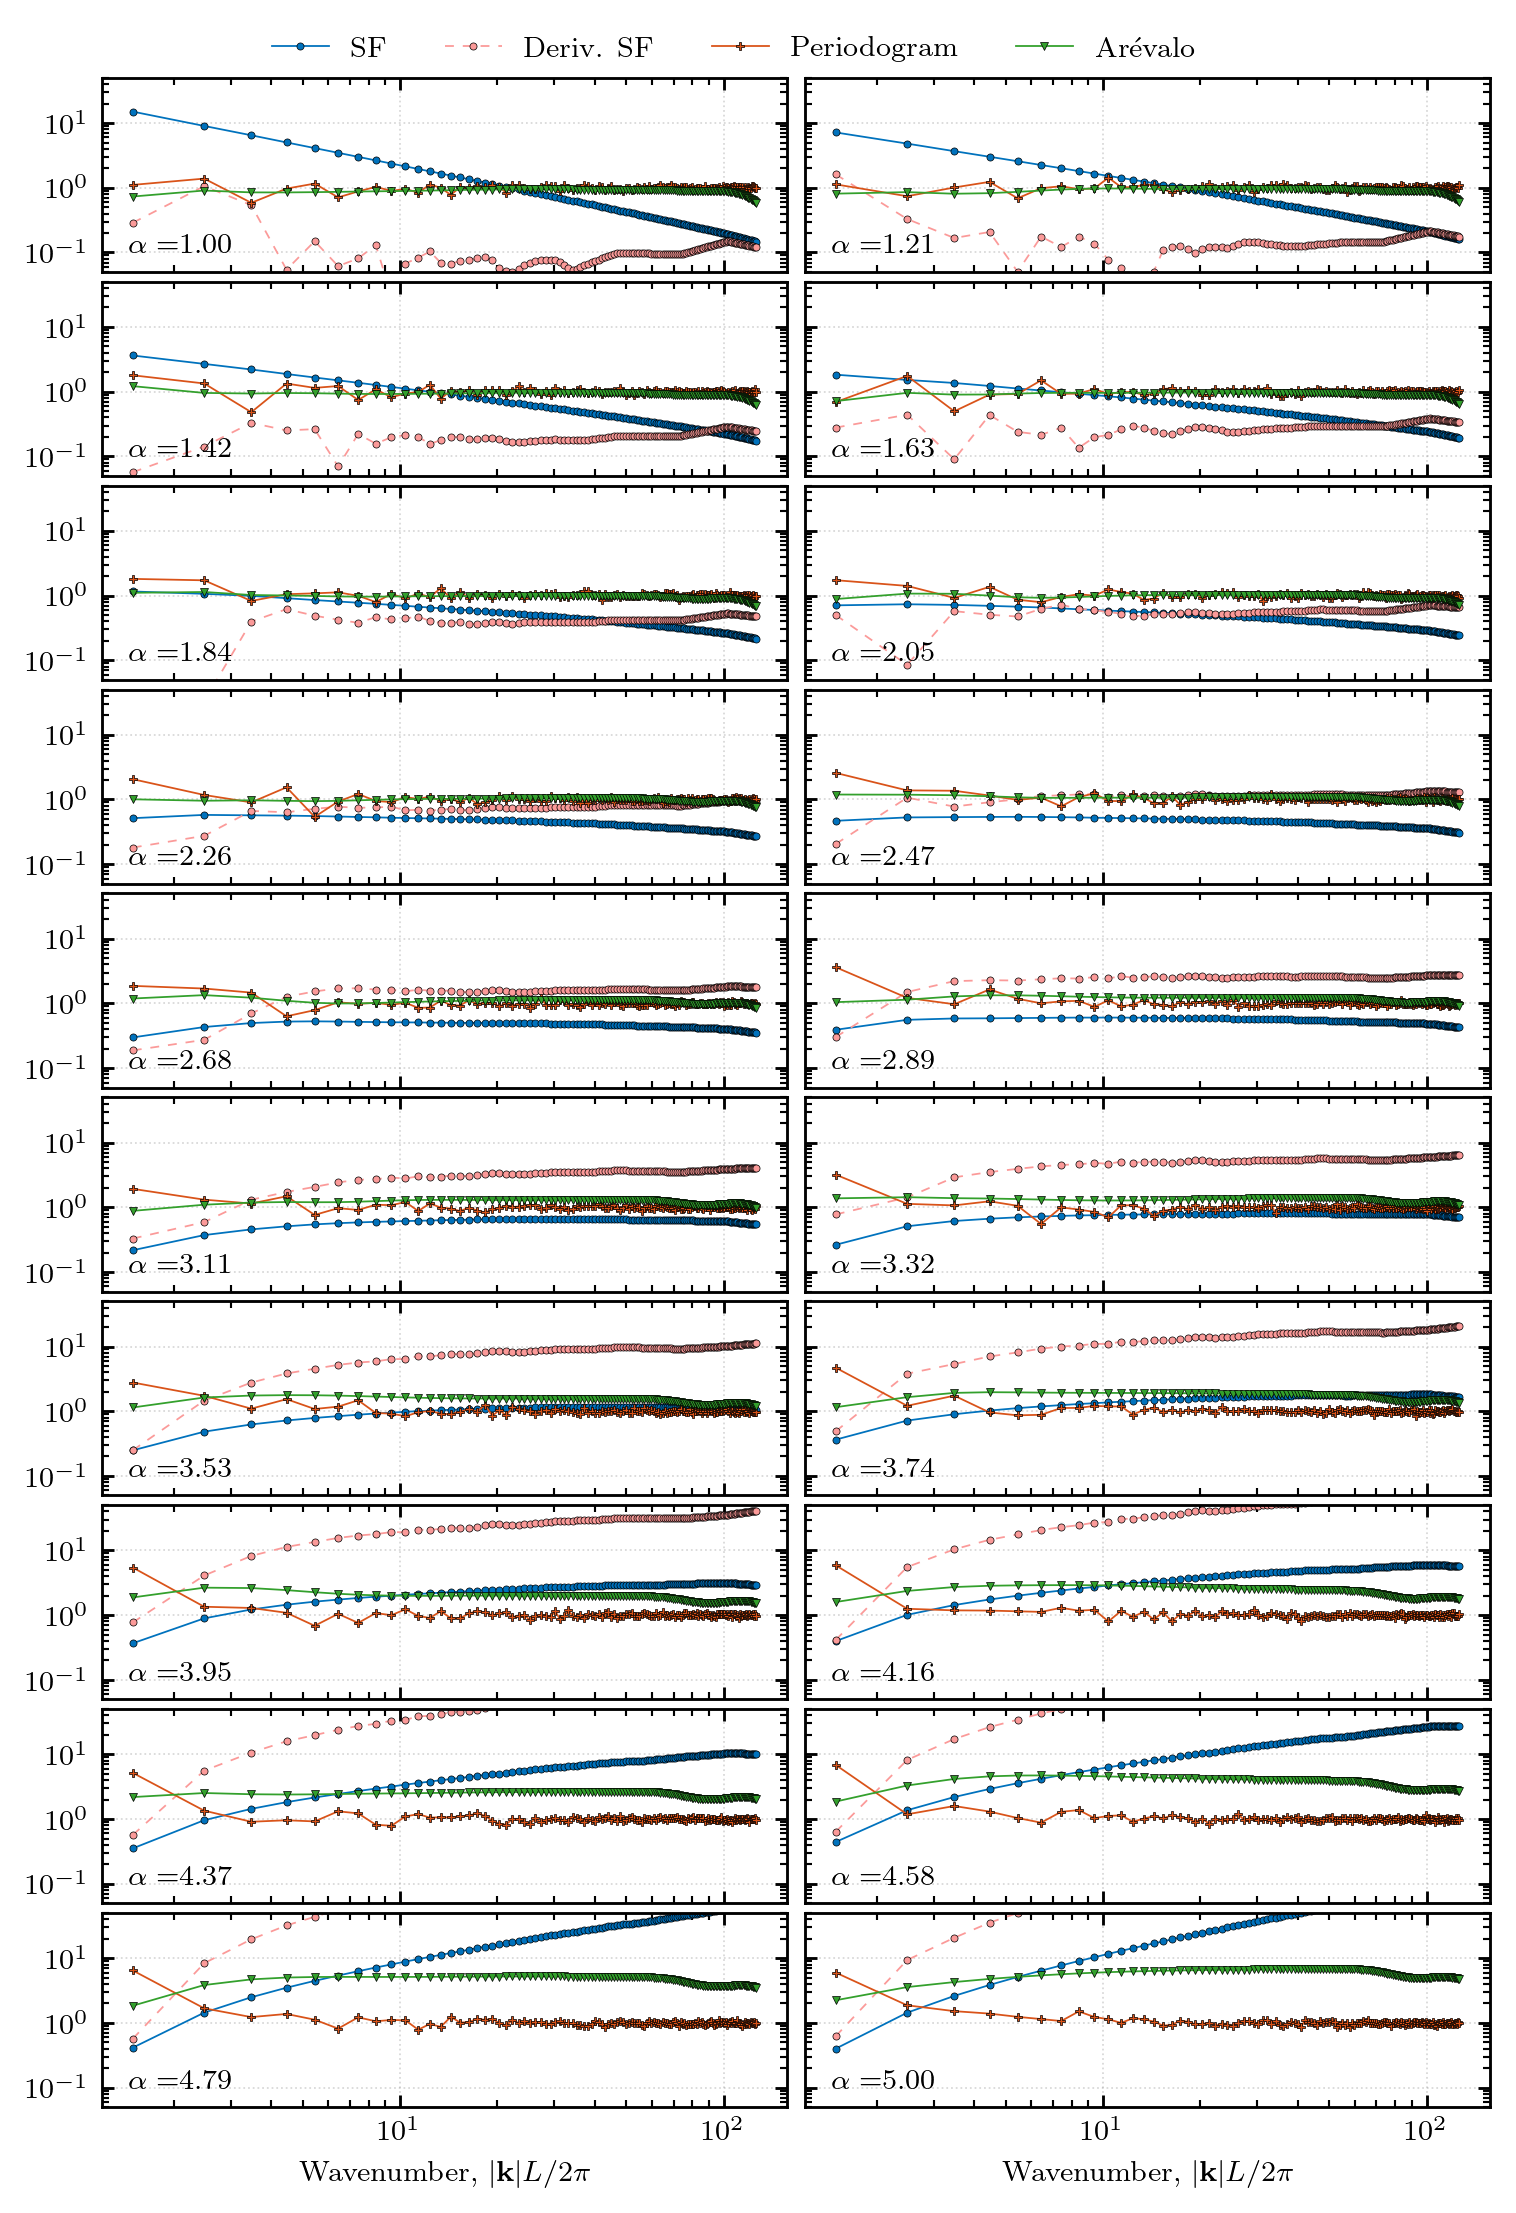

In [96]:
c = plotting.COLOR_CYCLE_6

fig, ax = plt.subplots(10, 2, figsize=(7., 10.5), dpi=256, sharex=True, sharey=True)

j = 0
for i, a in enumerate(sf_bias.keys()):
    k, bias = sf_bias[a]
    ax[j][i%2].plot(k, bias, linewidth=0.5, color=c[0], marker='o', markersize=2., markeredgecolor='black', markeredgewidth=0.2)
    if (i%2) == 1:
        j = j + 1
    #ax.scatter(a, sf_avg[a][0] - sf_avg[a][1], marker='o', s=5., color=c[0], zorder=2, linewidth=0.2, edgecolor='black')

j = 0
for i, a in enumerate(sf2_bias.keys()):
    k, bias = sf2_bias[a]
    ax[j][i%2].plot(k, bias, linewidth=0.5, color=c[3], marker='o', markersize=2., markeredgecolor='black', markeredgewidth=0.2, linestyle=(0, (5,5)))
    if (i%2) == 1:
        j = j + 1

j = 0
for i, a in enumerate(ek_bias.keys()):
    k, bias = ek_bias[a]
    ax[j][i%2].plot(k, bias, linewidth=0.5, color=c[1], marker='P', markersize=2., markeredgecolor='black', markeredgewidth=0.2)
    if (i%2) == 1:
        j = j + 1

j = 0
for i, a in enumerate(arevalo_bias.keys()):
    k, bias = arevalo_bias[a]
    ax[j][i%2].plot(k, bias, linewidth=0.5, color=c[2], marker='v', markersize=2., markeredgecolor='black', markeredgewidth=0.2)
    #ax[j][0].set_ylabel(r'Bias, $\tilde{E}(k)/E(k)$')
    if (i%2) == 1:
        j = j + 1

for aax in ax:
    for aaax in aax:
        aaax.yaxis.set_ticks_position('both')
        aaax.xaxis.set_ticks_position('both')
        aaax.tick_params(axis='y', direction='in')
        aaax.tick_params(axis='x', direction='in')
        aaax.tick_params(axis='y', direction='in', which='minor')
        aaax.tick_params(axis='x', direction='in', which='minor')

        aaax.set_xscale('log')
        aaax.set_yscale('log')
        aaax.grid(linestyle=':', alpha=0.3, linewidth=0.5, color='gray')

        aaax.set_ylim((5e-2, 5e1))
        #aaax.set_yticks([1e-1, 1e0, 1e1])

j = 0
for i, a in enumerate(arevalo_bias.keys()):
    ax[j][i%2].text(1.45, 0.1, r'$\alpha=$%0.2f' % a, color='black', transform=ax[j][i%2].get_xaxis_transform())#, bbox={'facecolor': 'gray', 'alpha': 0.5, 'edgecolor': 'none'})
    if (i%2) == 1:
        j = j + 1

ax[-1][0].set_xlabel('Wavenumber, $|\mathbf{k}|L/2\pi$')
ax[-1][1].set_xlabel('Wavenumber, $|\mathbf{k}|L/2\pi$')

ax[0][0].plot([], [], linewidth=0.5, color=c[0], marker='o', markersize=2., markeredgecolor='black', markeredgewidth=0.2, label=r'SF')
ax[0][0].plot([], [], linewidth=0.5, color=c[3], marker='o', markersize=2., markeredgecolor='black', markeredgewidth=0.2, linestyle=(0,(5,5)), label=r'Deriv. SF')
ax[0][0].plot([], [], linewidth=0.5, color=c[1], marker='P', markersize=2., markeredgecolor='black', markeredgewidth=0.2, label=r'Periodogram')
ax[0][0].plot([], [], linewidth=0.5, color=c[2], marker='v', markersize=2., markeredgecolor='black', markeredgewidth=0.2, label=r'Ar\'evalo')
#ax.plot([], [], color='black', linewidth=0.5, linestyle=(0,(5,5)), label=r'Analytical Ar\'evalo')
fig.legend(fancybox=False, frameon=False, ncol=4, bbox_to_anchor=(0.75, 0.905))

#leg = ax2.legend(ncol=6, bbox_to_anchor=(0.8, 1.18), fancybox=False, shadow=False, frameon=False)
#leg.get_frame().set_edgecolor('black')

fig.subplots_adjust(hspace=0.05, wspace=0.025)

#fig.subplots_adjust(wspace=0.05)
fig.savefig('plots/fbm_spectra_bias_resid.pdf', transparent=True, bbox_inches='tight', pad_inches=0)
fig.savefig('plots/fbm_spectra_bias_resid.png', transparent=True, bbox_inches='tight', pad_inches=0)
